In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Paths
BASE_DIR      = Path().resolve().parent
RAW_DIR       = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

# Load data
nav  = pd.read_csv(PROCESSED_DIR / "clean_nav_history.csv", parse_dates=["date"])
fund = pd.read_csv(RAW_DIR / "01_fund_master.csv")
bench = pd.read_csv(RAW_DIR / "10_benchmark_indices.csv", parse_dates=["date"])
perf  = pd.read_csv(RAW_DIR / "07_scheme_performance.csv")

# Merge nav with fund names
nav = nav.merge(fund[["amfi_code", "scheme_name", "expense_ratio_pct"]], on="amfi_code", how="left")

print("Data loaded!")
print(f"NAV rows     : {len(nav):,}")
print(f"Bench rows   : {len(bench):,}")
print(f"Funds        : {nav['amfi_code'].nunique()}")

Data loaded!
NAV rows     : 64,320
Bench rows   : 8,050
Funds        : 40


Daily Return Statistics:
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64


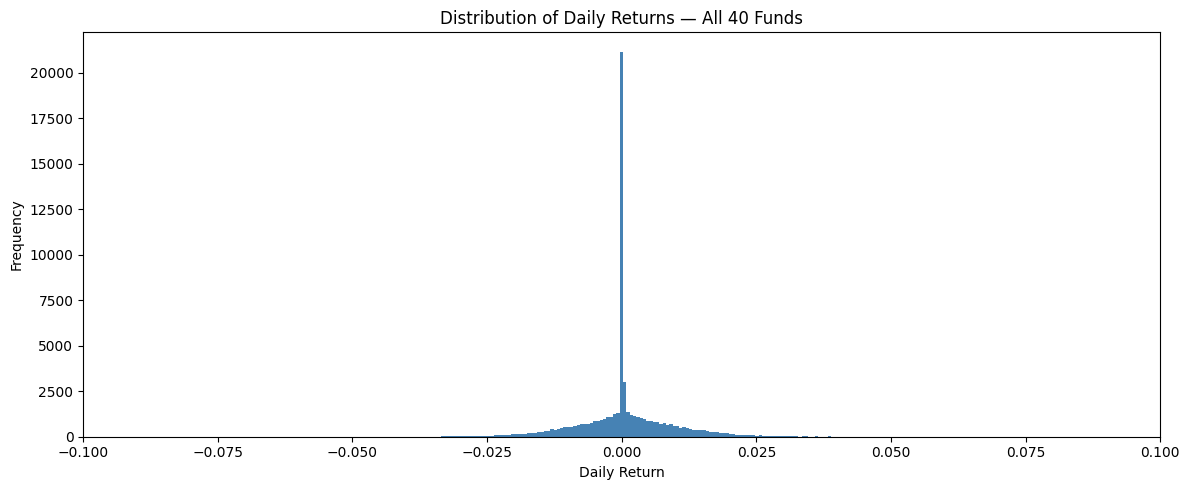


Daily returns computed successfully!


In [4]:
# Task 1 — Daily Returns
nav = nav.sort_values(["amfi_code", "date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Validate distribution
print("Daily Return Statistics:")
print(nav["daily_return"].describe())

# Plot distribution
plt.figure(figsize=(12, 5))
plt.hist(nav["daily_return"].dropna(), bins=200, color="steelblue", edgecolor="none")
plt.title("Distribution of Daily Returns — All 40 Funds")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.xlim(-0.1, 0.1)
plt.tight_layout()
plt.show()

print("\nDaily returns computed successfully!")

In [6]:
# Task 2 — CAGR for 1yr, 3yr, 5yr
def compute_cagr(nav_df, years):
    end_date   = nav_df["date"].max()
    start_date = end_date - pd.DateOffset(years=years)
    
    results = []
    for code, group in nav_df.groupby("amfi_code"):
        group = group.sort_values("date")
        period = group[group["date"] >= start_date]
        
        if len(period) < 2:
            continue
            
        nav_start = period.iloc[0]["nav"]
        nav_end   = period.iloc[-1]["nav"]
        n_days    = (period.iloc[-1]["date"] - period.iloc[0]["date"]).days
        n_years   = n_days / 365.25
        
        if n_years <= 0 or nav_start <= 0:
            continue
            
        cagr = (nav_end / nav_start) ** (1 / n_years) - 1
        results.append({
            "amfi_code": code,
            "scheme_name": group.iloc[0]["scheme_name"],
            f"cagr_{years}yr": round(cagr * 100, 2)
        })
    
    return pd.DataFrame(results)

cagr_1yr = compute_cagr(nav, 1)
cagr_3yr = compute_cagr(nav, 3)
cagr_5yr = compute_cagr(nav, 5)

# Merge into one table
cagr = cagr_1yr.merge(cagr_3yr[["amfi_code", "cagr_3yr"]], on="amfi_code")
cagr = cagr.merge(cagr_5yr[["amfi_code", "cagr_5yr"]], on="amfi_code")

print("CAGR Table:")
print(cagr.sort_values("cagr_3yr", ascending=False).to_string(index=False))
cagr.to_csv(BASE_DIR / "data" / "processed" / "cagr_report.csv", index=False)

CAGR Table:
 amfi_code                                           scheme_name  cagr_1yr  cagr_3yr  cagr_5yr
    119094                   Axis Midcap Fund - Regular - Growth     22.28     35.10     28.21
    148567         Mirae Asset Large Cap Fund - Regular - Growth     20.38     33.99     30.97
    120504             ICICI Pru Bluechip Fund - Direct - Growth     13.07     32.48     23.30
    100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth     53.28     32.43     30.12
    120505              ICICI Pru Midcap Fund - Regular - Growth     29.63     31.77     32.83
    119551             SBI Bluechip Fund - Regular Plan - Growth     60.49     30.45     25.80
    120843                Kotak Flexicap Fund - Regular - Growth     26.68     29.58     30.91
    148569         Mirae Asset Tax Saver Fund - Regular - Growth     39.78     29.17     31.95
    101206         ABSL Frontline Equity Fund - Regular - Growth     47.96     28.96     23.54
    149324                 DSP Small C

In [8]:
# Task 3 — Sharpe Ratio
RF = 0.065 / 252  # Daily risk-free rate (6.5% annual)

sharpe_results = []
for code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    if len(returns) < 30:
        continue
    
    excess_returns = returns - RF
    sharpe = (excess_returns.mean() / returns.std()) * np.sqrt(252)
    
    sharpe_results.append({
        "amfi_code": code,
        "scheme_name": group.iloc[0]["scheme_name"],
        "sharpe_ratio": round(sharpe, 4)
    })

sharpe_df = pd.DataFrame(sharpe_results).sort_values("sharpe_ratio", ascending=False)
print("Top 10 Funds by Sharpe Ratio:")
print(sharpe_df.head(10).to_string(index=False))
sharpe_df.to_csv(BASE_DIR / "data" / "processed" / "sharpe_values.csv", index=False)

Top 10 Funds by Sharpe Ratio:
 amfi_code                                        scheme_name  sharpe_ratio
    148567      Mirae Asset Large Cap Fund - Regular - Growth        1.0682
    120843             Kotak Flexicap Fund - Regular - Growth        0.9656
    148569      Mirae Asset Tax Saver Fund - Regular - Growth        0.9190
    120505           ICICI Pru Midcap Fund - Regular - Growth        0.8833
    119551          SBI Bluechip Fund - Regular Plan - Growth        0.8610
    149323                 DSP Midcap Fund - Regular - Growth        0.8329
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth        0.8083
    118632     Nippon India Large Cap Fund - Regular - Growth        0.7589
    119094                Axis Midcap Fund - Regular - Growth        0.7305
    101206      ABSL Frontline Equity Fund - Regular - Growth        0.7174


In [10]:
# Task 4 — Sortino Ratio
sortino_results = []
for code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    if len(returns) < 30:
        continue
    
    excess_returns = returns - RF
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()
    
    if downside_std == 0:
        continue
    
    sortino = (excess_returns.mean() / downside_std) * np.sqrt(252)
    
    sortino_results.append({
        "amfi_code": code,
        "scheme_name": group.iloc[0]["scheme_name"],
        "sortino_ratio": round(sortino, 4)
    })

sortino_df = pd.DataFrame(sortino_results).sort_values("sortino_ratio", ascending=False)
print("Top 10 Funds by Sortino Ratio:")
print(sortino_df.head(10).to_string(index=False))
sortino_df.to_csv(BASE_DIR / "data" / "processed" / "sortino_values.csv", index=False)

Top 10 Funds by Sortino Ratio:
 amfi_code                                        scheme_name  sortino_ratio
    148567      Mirae Asset Large Cap Fund - Regular - Growth         1.4907
    120843             Kotak Flexicap Fund - Regular - Growth         1.4795
    148569      Mirae Asset Tax Saver Fund - Regular - Growth         1.3528
    119551          SBI Bluechip Fund - Regular Plan - Growth         1.2915
    120505           ICICI Pru Midcap Fund - Regular - Growth         1.2858
    149323                 DSP Midcap Fund - Regular - Growth         1.1678
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth         1.1442
    118632     Nippon India Large Cap Fund - Regular - Growth         1.0989
    119598         SBI Small Cap Fund - Regular Plan - Growth         1.0673
    120504          ICICI Pru Bluechip Fund - Direct - Growth         1.0640


In [12]:
# Task 5 — Alpha and Beta vs Nifty 100
nifty100 = bench[bench["index_name"] == "NIFTY100"].copy()
nifty100 = nifty100.sort_values("date")
nifty100["bench_return"] = nifty100["close_value"].pct_change()

alpha_beta_results = []
for code, group in nav.groupby("amfi_code"):
    group = group.sort_values("date")
    
    # Merge fund returns with benchmark returns on date
    merged = group[["date", "daily_return", "scheme_name"]].merge(
        nifty100[["date", "bench_return"]], on="date", how="inner"
    ).dropna()
    
    if len(merged) < 30:
        continue
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged["bench_return"],
        merged["daily_return"]
    )
    
    alpha = intercept * 252  # Annualise
    beta  = slope
    
    alpha_beta_results.append({
        "amfi_code": code,
        "scheme_name": merged.iloc[0]["scheme_name"],
        "alpha": round(alpha, 4),
        "beta":  round(beta, 4),
        "r_squared": round(r_value**2, 4)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results).sort_values("alpha", ascending=False)
print("Top 10 Funds by Alpha:")
print(alpha_beta_df.head(10).to_string(index=False))
alpha_beta_df.to_csv(BASE_DIR / "data" / "processed" / "alpha_beta.csv", index=False)

Top 10 Funds by Alpha:
 amfi_code                                        scheme_name  alpha    beta  r_squared
    119598         SBI Small Cap Fund - Regular Plan - Growth 0.3034 -0.0232     0.0001
    149324              DSP Small Cap Fund - Regular - Growth 0.3006  0.0115     0.0000
    120505           ICICI Pru Midcap Fund - Regular - Growth 0.2926  0.0005     0.0000
    148569      Mirae Asset Tax Saver Fund - Regular - Growth 0.2827  0.0181     0.0002
    120843             Kotak Flexicap Fund - Regular - Growth 0.2733 -0.0228     0.0003
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth 0.2720  0.0051     0.0000
    148567      Mirae Asset Large Cap Fund - Regular - Growth 0.2698  0.0237     0.0005
    149323                 DSP Midcap Fund - Regular - Growth 0.2660 -0.0025     0.0000
    119094                Axis Midcap Fund - Regular - Growth 0.2608 -0.0663     0.0019
    119551          SBI Bluechip Fund - Regular Plan - Growth 0.2320 -0.0318     0.0009


In [14]:
print("Benchmark index names:")
print(bench["index_name"].unique())

print("\nNifty100 date range:")
print(nifty100["date"].min(), "→", nifty100["date"].max())

print("\nNAV date range:")
print(nav["date"].min(), "→", nav["date"].max())

print("\nOverlapping dates:")
overlap = pd.merge(nifty100[["date"]], nav[["date"]].drop_duplicates(), on="date")
print(len(overlap), "matching dates")

Benchmark index names:
<ArrowStringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

Nifty100 date range:
2022-01-03 00:00:00 → 2026-05-29 00:00:00

NAV date range:
2022-01-03 00:00:00 → 2026-05-29 00:00:00

Overlapping dates:
1150 matching dates


In [16]:
# Task 6 — Maximum Drawdown
drawdown_results = []
for code, group in nav.groupby("amfi_code"):
    group = group.sort_values("date")
    
    # Running maximum
    group["running_max"] = group["nav"].cummax()
    
    # Drawdown at each point
    group["drawdown"] = group["nav"] / group["running_max"] - 1
    
    # Maximum drawdown
    max_dd = group["drawdown"].min()
    worst_date = group.loc[group["drawdown"].idxmin(), "date"]
    
    drawdown_results.append({
        "amfi_code"       : code,
        "scheme_name"     : group.iloc[0]["scheme_name"],
        "max_drawdown_pct": round(max_dd * 100, 2),
        "worst_date"      : worst_date
    })

drawdown_df = pd.DataFrame(drawdown_results).sort_values("max_drawdown_pct")
print("Top 10 Worst Drawdowns:")
print(drawdown_df.head(10).to_string(index=False))
drawdown_df.to_csv(BASE_DIR / "data" / "processed" / "max_drawdown.csv", index=False)

Top 10 Worst Drawdowns:
 amfi_code                                    scheme_name  max_drawdown_pct worst_date
    119599      SBI Small Cap Fund - Direct Plan - Growth            -52.57 2025-10-28
    119095         Axis Small Cap Fund - Regular - Growth            -51.68 2026-05-11
    101207         ABSL Small Cap Fund - Regular - Growth            -35.45 2026-05-11
    149324          DSP Small Cap Fund - Regular - Growth            -31.17 2025-01-03
    119598     SBI Small Cap Fund - Regular Plan - Growth            -28.71 2025-05-14
    102886            UTI Mid Cap Fund - Regular - Growth            -28.00 2026-04-27
    100016      HDFC Top 100 Fund - Regular Plan - Growth            -24.73 2022-09-15
    120842  Kotak Emerging Equity Fund - Regular - Growth            -24.00 2024-10-17
    118634 Nippon India Small Cap Fund - Regular - Growth            -23.34 2026-02-20
    119093           Axis Bluechip Fund - Direct - Growth            -21.75 2023-05-22


In [18]:
# Task 7 — Fund Scorecard (0-100)
# Merge all metrics
scorecard = cagr[["amfi_code", "scheme_name", "cagr_3yr"]].copy()
scorecard = scorecard.merge(sharpe_df[["amfi_code", "sharpe_ratio"]], on="amfi_code")
scorecard = scorecard.merge(alpha_beta_df[["amfi_code", "alpha"]], on="amfi_code")
scorecard = scorecard.merge(drawdown_df[["amfi_code", "max_drawdown_pct"]], on="amfi_code")
scorecard = scorecard.merge(fund[["amfi_code", "expense_ratio_pct"]], on="amfi_code")

# Rank each metric (higher rank = better)
scorecard["rank_3yr"]     = scorecard["cagr_3yr"].rank(ascending=True)
scorecard["rank_sharpe"]  = scorecard["sharpe_ratio"].rank(ascending=True)
scorecard["rank_alpha"]   = scorecard["alpha"].rank(ascending=True)
scorecard["rank_expense"] = scorecard["expense_ratio_pct"].rank(ascending=False)  # lower is better
scorecard["rank_maxdd"]   = scorecard["max_drawdown_pct"].rank(ascending=False)   # less negative is better

# Composite score
n = len(scorecard)
scorecard["score"] = (
    0.30 * scorecard["rank_3yr"]     +
    0.25 * scorecard["rank_sharpe"]  +
    0.20 * scorecard["rank_alpha"]   +
    0.15 * scorecard["rank_expense"] +
    0.10 * scorecard["rank_maxdd"]
) / n * 100

scorecard = scorecard.sort_values("score", ascending=False).reset_index(drop=True)
scorecard["rank"] = scorecard.index + 1

print("Top 10 Funds — Scorecard:")
print(scorecard[["rank", "scheme_name", "cagr_3yr", "sharpe_ratio", "alpha", "score"]].head(10).to_string(index=False))
scorecard.to_csv(BASE_DIR / "data" / "processed" / "fund_scorecard.csv", index=False)

Top 10 Funds — Scorecard:
 rank                                        scheme_name  cagr_3yr  sharpe_ratio  alpha   score
    1           ICICI Pru Midcap Fund - Regular - Growth     31.77        0.8833 0.2926 85.1250
    2                Axis Midcap Fund - Regular - Growth     35.10        0.7305 0.2608 82.0000
    3 HDFC Mid-Cap Opportunities Fund - Regular - Growth     32.43        0.8083 0.2720 80.5000
    4      Mirae Asset Large Cap Fund - Regular - Growth     33.99        1.0682 0.2698 80.0000
    5             Kotak Flexicap Fund - Regular - Growth     29.58        0.9656 0.2733 78.2500
    6         SBI Small Cap Fund - Regular Plan - Growth     26.66        0.7117 0.3034 75.7500
    7              DSP Small Cap Fund - Regular - Growth     26.99        0.7144 0.3006 75.5625
    8          ICICI Pru Bluechip Fund - Direct - Growth     32.48        0.7147 0.2119 75.1250
    9      Mirae Asset Tax Saver Fund - Regular - Growth     29.17        0.9190 0.2827 73.9375
   10         

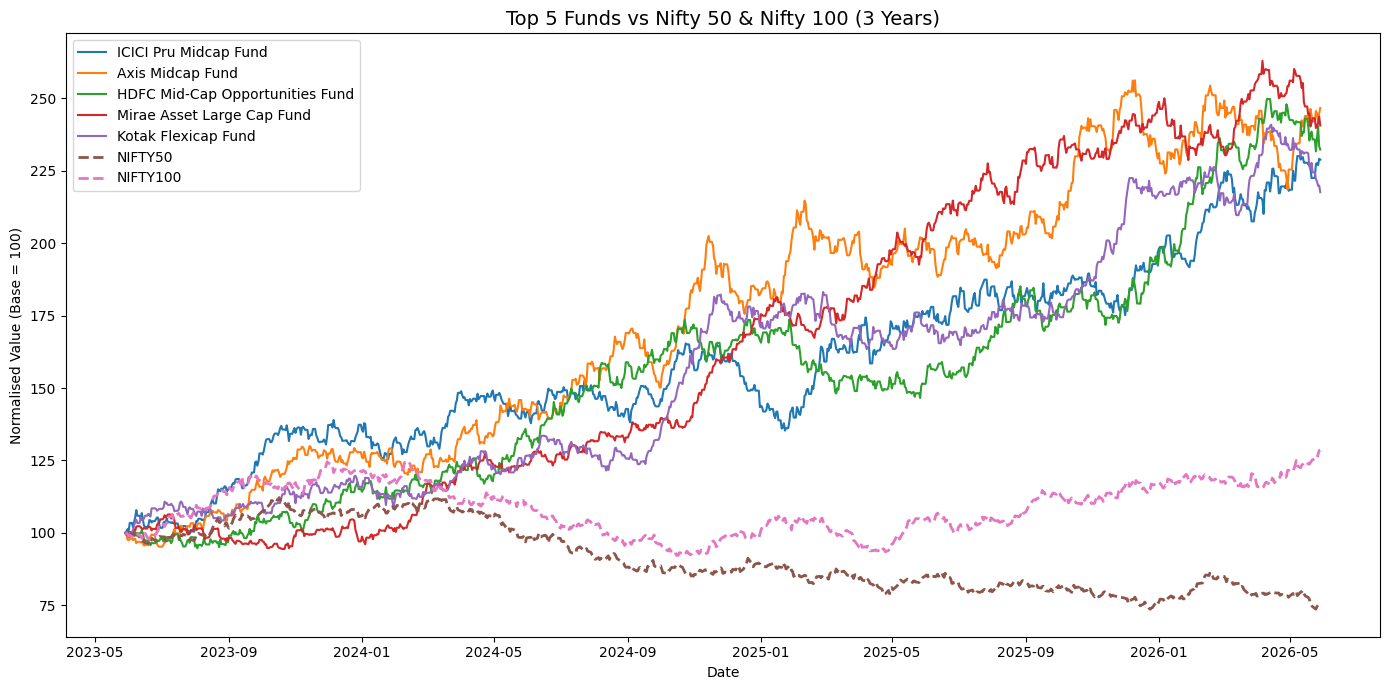


Tracking Error vs Nifty 100:
  ICICI Pru Midcap Fund                         TE: 0.2320
  Axis Midcap Fund                              TE: 0.2377
  HDFC Mid-Cap Opportunities Fund               TE: 0.2287
  Mirae Asset Large Cap Fund                    TE: 0.1897
  Kotak Flexicap Fund                           TE: 0.2064


In [19]:
# Task 8 — Benchmark Comparison Chart
# Get top 5 fund codes from scorecard
top5_codes = scorecard.head(5)["amfi_code"].tolist()
top5_nav = nav[nav["amfi_code"].isin(top5_codes)].copy()

# Filter last 3 years
three_years_ago = nav["date"].max() - pd.DateOffset(years=3)
top5_nav = top5_nav[top5_nav["date"] >= three_years_ago]

# Normalise NAV to 100 at start
top5_nav["nav_norm"] = top5_nav.groupby("amfi_code")["nav"].transform(
    lambda x: x / x.iloc[0] * 100
)

# Get Nifty50 and Nifty100
bench_filtered = bench[
    (bench["index_name"].isin(["NIFTY50", "NIFTY100"])) &
    (bench["date"] >= three_years_ago)
].copy()

bench_filtered["nav_norm"] = bench_filtered.groupby("index_name")["close_value"].transform(
    lambda x: x / x.iloc[0] * 100
)

# Plot
plt.figure(figsize=(14, 7))
for code in top5_codes:
    fund_data = top5_nav[top5_nav["amfi_code"] == code]
    name = fund_data.iloc[0]["scheme_name"].split(" - ")[0]
    plt.plot(fund_data["date"], fund_data["nav_norm"], label=name)

for idx in ["NIFTY50", "NIFTY100"]:
    b = bench_filtered[bench_filtered["index_name"] == idx]
    plt.plot(b["date"], b["nav_norm"], linestyle="--", linewidth=2, label=idx)

plt.title("Top 5 Funds vs Nifty 50 & Nifty 100 (3 Years)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Normalised Value (Base = 100)")
plt.legend()
plt.tight_layout()
plt.savefig(BASE_DIR / "reports" / "benchmark_chart.png", dpi=150)
plt.show()

# Tracking error
print("\nTracking Error vs Nifty 100:")
nifty100_returns = bench[bench["index_name"] == "NIFTY100"].copy()
nifty100_returns["bench_return"] = nifty100_returns["close_value"].pct_change()

for code in top5_codes:
    fund_data = nav[nav["amfi_code"] == code][["date", "daily_return", "scheme_name"]]
    merged = fund_data.merge(nifty100_returns[["date", "bench_return"]], on="date").dropna()
    tracking_error = (merged["daily_return"] - merged["bench_return"]).std() * np.sqrt(252)
    name = merged.iloc[0]["scheme_name"].split(" - ")[0]
    print(f"  {name:<45} TE: {tracking_error:.4f}")